In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import scipy.io as sio
import tensorflow as tf


import models as models

In [2]:
sigma1 = 0.5
sigma2 = 0.8
sigma3 = 0.6
mu1 = 0
mu2 = 2
mu3 = -2

eps = 5
T = 1



def prior_fn(x):
    T1 = (x - mu1) ** 2 / sigma1 ** 2
    f1 = 1 / np.sqrt(2*np.pi*sigma1**2) * np.exp(-T1/2)
    T2 = (x - mu2) ** 2 / sigma2 ** 2
    f2 = 1 / np.sqrt(2*np.pi*sigma2**2) * np.exp(-T2/2)
    T3 = (x - mu3) ** 2 / sigma3 ** 2
    f3 = 1 / np.sqrt(2*np.pi*sigma3**2) * np.exp(-T3/2)
    return f1 / 3 + f2 / 3 + f3 / 3


def posterior_fn(x, yt):
    T1 = (x - mu1) ** 2 / sigma1 ** 2
    f1 = 1 / np.sqrt(2*np.pi*sigma1**2) * np.exp(-T1/2)
    T2 = (x - mu2) ** 2 / sigma2 ** 2
    f2 = 1 / np.sqrt(2*np.pi*sigma2**2) * np.exp(-T2/2)
    T3 = (x - mu3) ** 2 / sigma3 ** 2
    f3 = 1 / np.sqrt(2*np.pi*sigma3**2) * np.exp(-T3/2)
    A = f1 / 3 + f2 / 3 + f3 / 3
    
    B = 1 / np.sqrt(2*np.pi*eps*T) * np.exp(-(x-yt) ** 2 / 2 / eps / T)
    
    T1 = (yt - mu1) ** 2 / (sigma1 ** 2 + eps * T)
    T2 = (yt - mu2) ** 2 / (sigma2 ** 2 + eps * T)
    T3 = (yt - mu3) ** 2 / (sigma3 ** 2 + eps * T)
    
    C1 = 1/C(T, sigma1) * np.exp(-T1/2)
    C2 = 1/C(T, sigma2) * np.exp(-T2/2)
    C3 = 1/C(T, sigma3) * np.exp(-T3/2)
    
    return A * B / (C1/3 + C2/3 + C3/3)


def C(t, sigma):
    return np.sqrt(2 * np.pi * (sigma ** 2 + eps * t))

#### NN

In [3]:
x = np.linspace(-5, 5, 1001)
model = models.NN(units=50, name="nn_1000000", eps=5, activation=tf.tanh)
model.restore()

forward_fn = tf.function(model.call)

In [4]:
dt = 0.0001

M = int(1e5)
yt = -3

_zts = [yt * np.ones([M, 1])]
t = 0
tt = tf.ones([M, 1])
for i in range(int(T/dt)):
        
    update = forward_fn(
        (T - t) * tt,
        tf.constant(_zts[-1].reshape([-1, 1]), tf.float32),            
    ).numpy()
    zt = _zts[-1] + eps * update * dt + \
        np.sqrt(eps) * np.random.normal(size=_zts[-1].shape) * np.sqrt(dt)
    _zts += [zt]
    t = t + dt
zts = np.stack(_zts, axis=0)

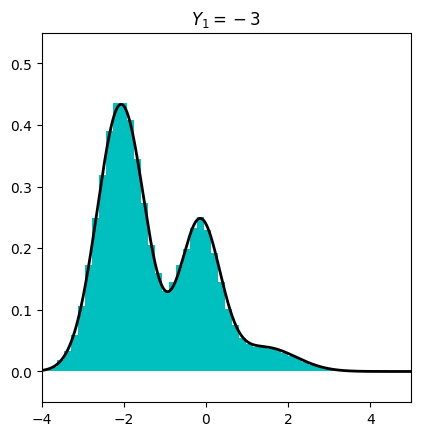

In [5]:
x = np.linspace(-4, 5, 10001)

plt.plot(x, posterior_fn(x, yt), "k-", linewidth=2)
plt.hist(zts[-1, :, 0], bins=50, density=True, color="c")
plt.title("$Y_1=-3$")
plt.ylim([-0.05, 0.55])
plt.xlim([-4, 5])
ax = plt.gca()
ax.set_box_aspect(1)
plt.savefig("./figs/sgm1.png")
plt.show()

In [6]:
sio.savemat(
    "./outputs/sgm1.mat", 
    {
        "x": x,
        "y": posterior_fn(x, yt),
        "samples": zts[-1, :, 0]
    },
)